<a href="https://colab.research.google.com/github/Anit-Paul/Machine-Learning/blob/main/ANN_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:00<00:00, 68.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/versions/2


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv(path+"/Churn_Modelling.csv")

In [14]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [19]:
df.drop('Surname',axis=1,inplace=True)

In [20]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [24]:
df.corr()['Exited']

,Exited
CreditScore,-0.027094
Age,0.285323
Tenure,-0.014001
Balance,0.118533
NumOfProducts,-0.047820
HasCrCard,-0.007138
IsActiveMember,-0.156128
EstimatedSalary,0.012097
Exited,1.000000
Geography_Germany,0.173488


In [23]:
df.drop(['RowNumber','CustomerId'],axis=1,inplace=True)

In [71]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Exited',axis=1),df['Exited'],test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [38]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Input
from keras.layers import Dropout

In [41]:
#hyper parameter tunning using keras-tuner
import keras_tuner as kt
def build_model(hp):
  model = Sequential()
  # Replace X_train.shape[1] with your number of input features
  model.add(Input(shape=(x_train.shape[1],)))
  # Tune the number of hidden layers: 1 to 4
  number_of_layers = hp.Int(
        name="number_of_layers",
        min_value=1,
        max_value=4,
        step=1
  )
  for i in range(number_of_layers):

        # Tune neurons separately for every hidden layer
        model.add(
            Dense(
                units=hp.Int(
                    name=f"units_{i}",
                    min_value=8,
                    max_value=128,
                    step=8
                ),
                activation=hp.Choice(
                    name=f"activation_{i}",
                    values=["relu", "tanh"]
                )
            )
        )
        # Tune dropout for every hidden layer
        model.add(
            Dropout(
                rate=hp.Float(
                    name=f"dropout_{i}",
                    min_value=0.0,
                    max_value=0.5,
                    step=0.1
                )
            )
        )

  # Output layer for binary classification
  model.add(Dense(1, activation="sigmoid"))
  # Tune optimizer and learning rate
  optimizer_name = hp.Choice(
      name="optimizer",
      values=["adam", "sgd", "rmsprop"]
  )

  # Create optimizer instance based on the chosen name
  if optimizer_name == "adam":
      optimizer_instance = keras.optimizers.Adam()
  elif optimizer_name == "sgd":
      optimizer_instance = keras.optimizers.SGD()
  elif optimizer_name == "rmsprop":
      optimizer_instance = keras.optimizers.RMSprop()
  else:
      raise ValueError(f"Unknown optimizer: {optimizer_name}")

  model.compile(
      optimizer=optimizer_instance,
      loss="binary_crossentropy",
      metrics=["accuracy"],
  )

  return model

In [53]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
     directory='myProject')

In [55]:
tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Trial 5 Complete [00h 00m 07s]
val_loss: 0.34165525436401367

Best val_loss So Far: 0.34165525436401367
Total elapsed time: 00h 00m 29s


In [56]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [57]:
tuner.get_best_hyperparameters()[0].values

{'number_of_layers': 4,
 'units_0': 112,
 'activation_0': 'tanh',
 'dropout_0': 0.1,
 'optimizer': 'adam',
 'units_1': 80,
 'activation_1': 'tanh',
 'dropout_1': 0.1,
 'units_2': 8,
 'activation_2': 'relu',
 'dropout_2': 0.0,
 'units_3': 8,
 'activation_3': 'relu',
 'dropout_3': 0.0}

In [58]:
best_model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [59]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 112)            │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         9,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,113 (43.41 KB)

 Trainable params: 11,113 (43.41 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
#using early stopping
from keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor='val_loss',patience=10)

In [61]:
best_model.fit(x_train,y_train,epochs=500,validation_data=(x_test,y_test),callbacks=[early_stopping])

Epoch 1/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8579 - loss: 0.3470 - val_accuracy: 0.8650 - val_loss: 0.3389
Epoch 2/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8572 - loss: 0.3420 - val_accuracy: 0.8625 - val_loss: 0.3409
Epoch 3/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8583 - loss: 0.3390 - val_accuracy: 0.8595 - val_loss: 0.3471
Epoch 4/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8577 - loss: 0.3402 - val_accuracy: 0.8650 - val_loss: 0.3361
Epoch 5/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8591 - loss: 0.3382 - val_accuracy: 0.8620 - val_loss: 0.3413
Epoch 6/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8619 - loss: 0.3380 - val_accuracy: 0.8655 - val_loss: 0.3350
Epoch 7/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8605 - loss: 0.3344 - val_accuracy: 0.8605 - val_loss: 0.3374
Epoch 8/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8614 - loss: 0.3339 - val_accu

In [63]:
test_loss, test_accuracy = best_model.evaluate(x_test, y_test)
print(test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8600 - loss: 0.3498
0.8600000143051147


In [64]:
y_pred_prob = best_model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.86
Precision: 0.6793650793650794
Recall   : 0.544529262086514
F1 Score : 0.6045197740112994


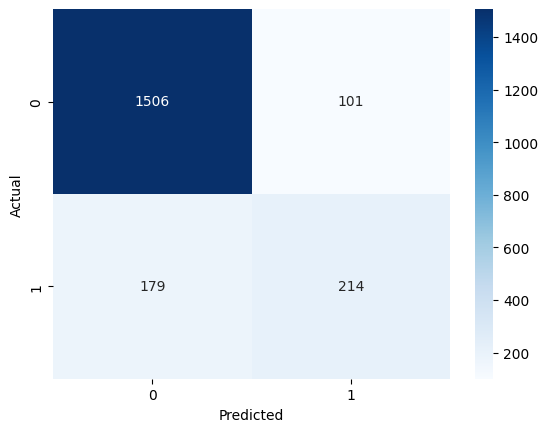

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
best_model.save("best_ann_model.keras")

In [68]:
#also saving the preprocessing object
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [69]:
from google.colab import files

files.download("best_ann_model.keras")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])